In [1]:
# This file is a jupytext-paired Python script export of
# `building_decision_models_solution.ipynb`. The canonical artifact for learners is
# the notebook (.ipynb); this script is provided for code review and `git diff`
# readability. Run `jupytext --sync` to keep the two in lockstep after edits.

# Structuring and Solving a Product Launch Decision (SOLUTION)

## Scenario

Pace & Pivot Gear's Head of Strategy described three options for the Apex Trainer launch
verbally. This notebook turns that description into a structured Python decision
model: an influence diagram mapping the dependencies, OPTIONS and STATES defined
from the narrative, a reusable `option_profit` function, a payoff matrix built by
calling it, and a decision tree that enumerates all paths through the structure.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_PATH = "../building-decision-models-starter/data/sporting_goods_sales.csv"

## 1. Derive state probabilities from real market data

In [3]:
sales = pd.read_csv(DATA_PATH)
sales.columns = ["date", "sales_m"]
sales["date"] = pd.to_datetime(sales["date"])
sales["yoy"] = sales["sales_m"].pct_change(12) * 100
sales = sales.dropna(subset=["yoy"])

t33, t67 = sales["yoy"].quantile([1/3, 2/3])
print(f"YoY growth thresholds: Low/Base at {t33:.2f}%, Base/High at {t67:.2f}%")

def classify(x):
    if x >= t67:  return "High"
    if x >= t33:  return "Base"
    return "Low"

sales["state"] = sales["yoy"].apply(classify)
counts = sales["state"].value_counts()
STATES = (counts / counts.sum()).reindex(["High", "Base", "Low"]).to_dict()

print("\nState probabilities (from data):")
for state, prob in STATES.items():
    print(f"  {state}: {prob:.3f}")

YoY growth thresholds: Low/Base at 1.07%, Base/High at 3.11%

State probabilities (from data):
  High: 0.343
  Base: 0.324
  Low: 0.333


By construction, tertile binning gives ~1/3 each. The threshold values come from
real data and anchor the probabilities to historical sporting goods market variation.

## 2. Influence diagram — map the structure before writing any code

Before defining options or writing a payoff function, draw the dependency structure
of the decision. Three node types:

- **Rectangle** — Decision node: a variable *you* control
- **Oval** — Uncertainty node: an uncertain variable nature controls
- **Rounded rectangle** — Value node: the payoff that depends on both

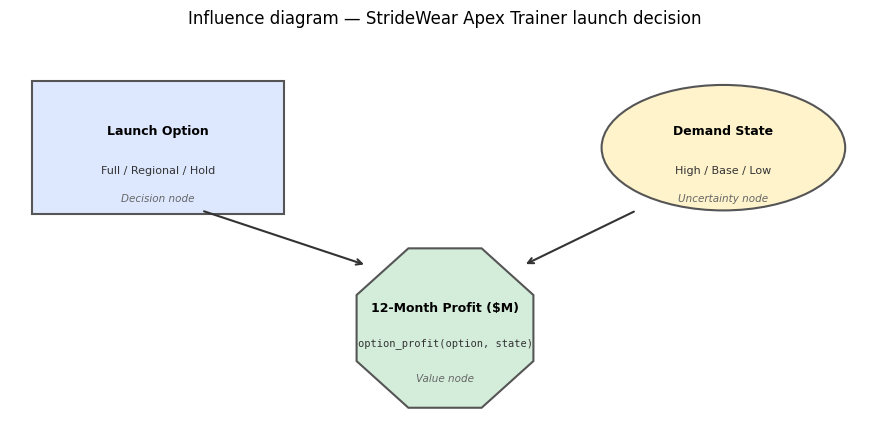

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis("off")
ax.set_title("Influence diagram — Pace & Pivot Gear Apex Trainer launch decision", pad=10)

# Decision node — rectangle (top-left)
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 2.8), 2.8, 1.6, boxstyle="square,pad=0.05",
    fc="#dde8ff", ec="#555", lw=1.5, zorder=2))
ax.text(1.7, 3.8, "Launch Option", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(1.7, 3.3, "Full / Regional / Hold", ha="center", va="center", fontsize=8, color="#333")
ax.text(1.7, 2.95, "Decision node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Uncertainty node — oval (top-right)
ax.add_patch(mpatches.Ellipse(
    (8.2, 3.6), 2.8, 1.6, fc="#fff3cc", ec="#555", lw=1.5, zorder=2))
ax.text(8.2, 3.8, "Demand State", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(8.2, 3.3, "High / Base / Low", ha="center", va="center", fontsize=8, color="#333")
ax.text(8.2, 2.95, "Uncertainty node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Value node — octagon (bottom-center)
import numpy as np
ax.add_patch(mpatches.RegularPolygon(
    (5.0, 1.3), numVertices=8, radius=1.1, orientation=np.pi/8,
    fc="#d4edda", ec="#555", lw=1.5, zorder=2))
ax.text(5.0, 1.55, "12-Month Profit ($M)", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(5.0, 1.1, "option_profit(option, state)", ha="center", va="center",
        fontsize=7.5, color="#333", family="monospace")
ax.text(5.0, 0.65, "Value node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Arrows: Decision → Profit, Demand State → Profit
ax.annotate("", xy=(4.1, 2.1), xytext=(2.2, 2.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))
ax.annotate("", xy=(5.9, 2.1), xytext=(7.2, 2.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

plt.tight_layout()
plt.show()

There is no arrow between the Decision node and the Chance node. That encodes a
key modelling assumption: Pace & Pivot Gear's launch choice does not change the demand
environment — whether the market turns out High, Base, or Low is independent of
which option they pick. This assumption might be wrong if a splashy Full Launch
generates enough buzz to shift demand upward; in that case you would add the arrow,
and the model would need to capture that dependency explicitly.

The diagram is the design. Steps 3–8 build what the diagram describes.

## 3. Define the structure

In [5]:
OPTIONS = ["Full Launch", "Regional Rollout", "Hold"]

FULL_LAUNCH_COST_M = 0.6
FULL_LAUNCH_REV_M  = {"High": 12.0, "Base": 4.0, "Low": -4.0}

REGIONAL_COST_M    = 0.2
REGIONAL_REV_M     = {"High": 5.5,  "Base": 2.0, "Low":  0.5}

## 4. Implement `option_profit`

In [6]:
def option_profit(option: str, demand_state: str) -> float:
    """Net 12-month profit ($M) for a given option and demand state."""
    if option == "Full Launch":
        return FULL_LAUNCH_REV_M[demand_state] - FULL_LAUNCH_COST_M
    if option == "Regional Rollout":
        return REGIONAL_REV_M[demand_state] - REGIONAL_COST_M
    if option == "Hold":
        return 0.0
    raise ValueError(f"Unknown option: {option}")


assert option_profit("Full Launch", "High")     == 11.4
assert option_profit("Regional Rollout", "Low") ==  0.3
assert option_profit("Hold", "Base")            ==  0.0

## 5. Build the payoff matrix

In [7]:
payoffs = pd.DataFrame(
    {state: {opt: option_profit(opt, state) for opt in OPTIONS}
     for state in STATES}
)
payoffs

,High,Base,Low
Full Launch,11.4,3.4,-4.6
Regional Rollout,5.3,1.8,0.3
Hold,0.0,0.0,0.0


## 6. Expected value per option

In [8]:
ev = (payoffs * pd.Series(STATES)).sum(axis=1)

print("Expected value per option ($M):")
print(ev.round(2))
print(f"\nEV-maximizing option: {ev.idxmax()}  (${ev.max():.2f}M)")

Expected value per option ($M):
Full Launch         3.47
Regional Rollout    2.50
Hold                0.00
dtype: float64

EV-maximizing option: Full Launch  ($3.47M)


## 7. Minimax regret

In [9]:
best_per_state = payoffs.max(axis=0)
regret         = best_per_state - payoffs
max_regret     = regret.max(axis=1)

print("Max regret per option ($M):")
print(max_regret.round(2))
print(f"\nMinimax-regret option: {max_regret.idxmin()}  "
      f"(max regret ${max_regret.min():.2f}M)")

Max regret per option ($M):
Full Launch          4.9
Regional Rollout     6.1
Hold                11.4
dtype: float64

Minimax-regret option: Full Launch  (max regret $4.90M)


## 8. Decision tree visualization

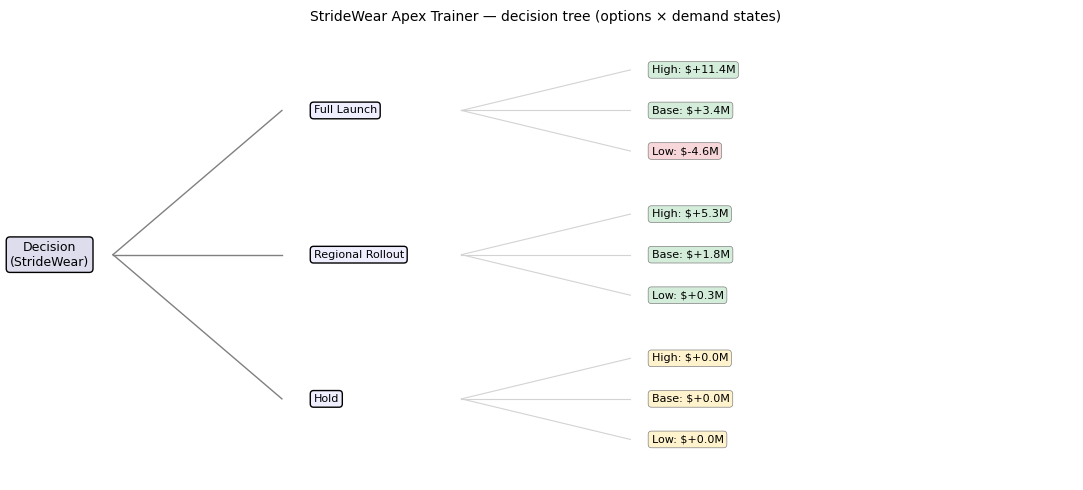

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis("off")

ax.text(0.03, 0.5, "Decision\n(Pace & Pivot Gear)", ha="center", va="center",
        bbox=dict(boxstyle="round", fc="#dde"), fontsize=9)

opt_y = np.linspace(0.82, 0.18, len(OPTIONS))
state_labels = list(STATES.keys())

for y, opt in zip(opt_y, OPTIONS):
    ax.plot([0.09, 0.25], [0.5, y], color="grey", lw=1)
    ax.text(0.28, y, opt, ha="left", va="center",
            bbox=dict(boxstyle="round", fc="#eef"), fontsize=8)

    state_y = np.linspace(y + 0.09, y - 0.09, len(state_labels))
    for sy, state in zip(state_y, state_labels):
        profit = option_profit(opt, state)
        ax.plot([0.42, 0.58], [y, sy], color="lightgrey", lw=0.8)
        color = "#d4edda" if profit > 0 else "#f8d7da" if profit < 0 else "#fff3cd"
        ax.text(0.60, sy, f"{state}: ${profit:+.1f}M",
                va="center", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc=color, ec="grey", lw=0.5))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Pace & Pivot Gear Apex Trainer — decision tree (options × demand states)",
             fontsize=10)
plt.tight_layout()
plt.show()

The influence diagram in step 2 showed three nodes and two arrows — the structure.
This tree enumerates all 9 paths through that structure: 3 options × 3 demand states,
with each leaf coloured by whether the profit is positive, negative, or zero.
The diagram was the design; the tree is the full enumeration.